Python_17_深層学習　（転移学習）

In [ ]:
# 写真にゴルフ場が写っているかいないかを見分ける　転移学習
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "nagaoka_gis/train",
    image_size=(224, 224), #MobileNetV2　モデルで利用できるサイズに
    label_mode="binary", #2値分類（binary）：あるかないか、の2値だから
    batch_size=32, #1回の学習で何枚の画像を使うか。デフォルト32のまま
    shuffle=True #読み込み順。学習用だけシャッフルして利用
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "nagaoka_gis/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)


# データを表示。 image_dataset_from_directory() はそのまま見れない
list(train_dataset.as_numpy_iterator())[0]

#カラー画像を読み込むと、画像の高さ（縦） x 画像の幅（横） x 3（RGB）
# の3次元の配列(array)形式のデータ

#2つ目の要素はラベル（正解値)。ゴルフ場が写っているかによって
#0か1の値が格納されている.
#★　image_dataset_from_directory() は、画像ファイルが保存されている
#フォルダ構造から、ラベル（正解値）を自動的に取得する仕組み。



Found 20 files belonging to 2 classes.
Found 6 files belonging to 2 classes.


(array([[[[ 55.71684  ,  84.00255  ,  58.71684  ],
          [ 75.686226 , 106.686226 ,  65.66326  ],
          [ 74.29592  , 104.29592  ,  69.01532  ],
          ...,
          [137.0817   , 147.0817   , 122.08169  ],
          [151.81363  , 160.08914  , 135.95139  ],
          [161.67093  , 166.67093  , 143.67093  ]],
 
         [[ 68.563774 ,  98.21939  ,  64.51276  ],
          [ 78.35459  , 108.35459  ,  71.53827  ],
          [ 76.053566 , 105.053566 ,  74.57143  ],
          ...,
          [153.72197  , 161.72197  , 137.72197  ],
          [162.4999   , 166.76526  , 143.83922  ],
          [168.33162  , 168.77805  , 147.29591  ]],
 
         [[ 83.88265  , 114.59694  ,  74.03062  ],
          [ 48.94898  ,  78.63776  ,  45.714287 ],
          [ 70.37754  ,  98.37754  ,  73.602036 ],
          ...,
          [164.41827  , 169.41827  , 146.41827  ],
          [168.49992  , 167.47188  , 146.47188  ],
          [171.46683  , 167.1556   , 146.92601  ]],
 
         ...,
 
         [[ 

In [4]:
#続き
# 分類名＊フォルダ名（no／yes）をリストとして格納する
class_names = train_dataset.class_names
class_names

['no', 'yes']

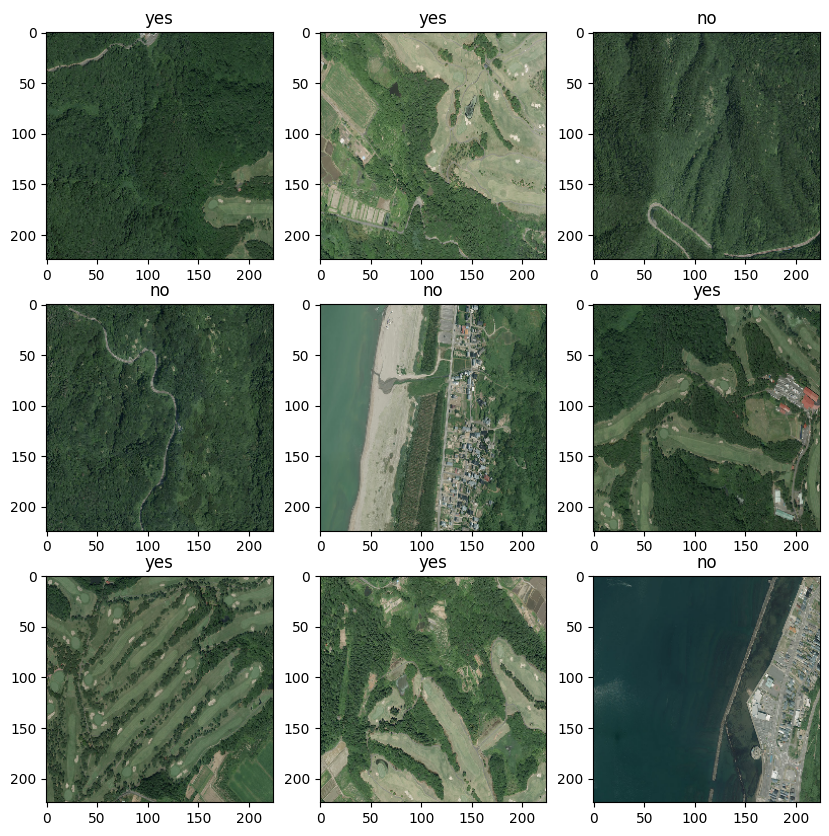

In [ ]:

#matplotlib.pyplotをインポートして、画像を表に表すことも可能。
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8")) #uintタイプミス多い
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])
    


In [20]:

# 画像を水増しする。　そのための関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label



In [21]:
# 画像の水増し処理の実行
# map()は非破壊メソッド。新しい変数へ格納する
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [22]:
# 水増ししたデータを訓練データに追加（連結）する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [25]:
# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

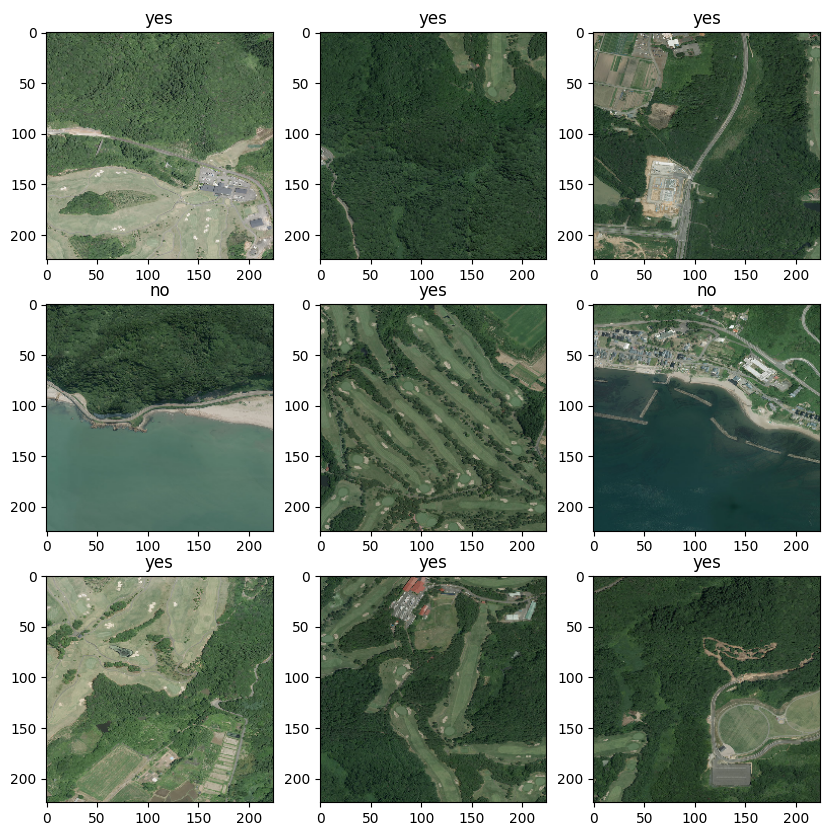

In [26]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [ ]:
#MobileNetV2 の学習済みモデルで、今回の訓練データを転移学習

# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層
# 入力層と正規化する層を結合
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer) 
  # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),#ピクセル数タテ、ヨコ×色数RGB(3)
    input_tensor=l_layer, #入力層を指定
    include_top=False, #出力層を自分で作成するためFalse。転移学習を可能に。
    weights="imagenet", #mageNet(大規模データセット)で学習した重みを利用
    pooling='avg' #プーリング層(畳み込み層)の出力を縮小するための層の計算手法
)
base_model.trainable = False
#出力層でのみ、入力された画像を学習するという指定
# Trueにするとファインチューニングとなる

# 上記実行で、入力層 -> 正規化する層 -> 学習済みのMobileNetV2モデル という並びの
# モデルが作成され、base_model という変数に格納された状態になる。

In [31]:
# 次に　Dense層（出力層）を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')
#”１”は、出力層のノード数。
# 今回、モデルから出力される結果は一つ（0か1）しかないので”１”

#　activation には、「活性化関数」を指定。
# 今回は、2値分類の際に有効な sigmoid という関数名を指定


In [ ]:
#モデルを完成させる
# base_modelに出力層（Dense層）を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

#入力層 -> 正規化する層 → 学習済みMobileNetV2モデル -> 出力層という
#流れのモデルが完成。最後にコンパイルして仕上げ

# modelをcompileする
model.compile(optimizer="adam", #今回のケースは adam という最適化手法
              loss='binary_crossentropy', #損失関数 正解との差を計算
              # 2値分類の際に有効な binary_crossentropy という関数名を指定
              metrics=["accuracy"]) #評価関数。モデルの評価方法。正解率（accuracy）のみ指定。


In [36]:
#期待する性能が出たかを評価する

# modelに学習させる
model.fit(train_dataset, epochs=20) #epochはデータセットの学習回#
#学習済みモデル利用のため少ない回数でも精度の高いモデルが作れる
# （逆に学習が多すぎると過学習が発生しやすくなる）ため、20を指定

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 635ms/step - accuracy: 0.6406 - loss: 0.6611
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 839ms/step - accuracy: 0.8085 - loss: 0.4598
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 730ms/step - accuracy: 0.9399 - loss: 0.2919
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 789ms/step - accuracy: 0.9765 - loss: 0.1983
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 629ms/step - accuracy: 0.9885 - loss: 0.1638
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 714ms/step - accuracy: 0.9813 - loss: 0.1149
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 670ms/step - accuracy: 1.0000 - loss: 0.1088
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 654ms/step - accuracy: 1.0000 - loss: 0.0659
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 654ms/step - accuracy: 1.0000 - loss: 0.0609
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 753ms/step - accuracy: 1.0000 - loss: 0.0517
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 725ms/step - accuracy: 1.0000 - loss: 0.0476
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 713ms/step - accuracy: 1.0000 - l

In [37]:
#この学習済モデルを使って性能評価

# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [ ]:
# 分類した結果を確認する。
# 0に近いほどゴルフ場は写っていない可能性が高く、
# 1に近いほどゴルフ場は写っている可能性が高い、
pred_data

array([[0.09506402],
       [0.4887747 ],
       [0.14221235],
       [0.984571  ],
       [0.5731263 ],
       [0.9324718 ]], dtype=float32)

In [40]:
#わかりづらいのでmodel が持つ evaluate() を実行

# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 1.0000 - loss: 0.2611


[0.2610582411289215, 1.0]